In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [33]:
df = pd.read_csv("leaves_training_final.csv")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         400 non-null    object 
 1   length       400 non-null    float64
 2   width        400 non-null    float64
 3   texture      400 non-null    object 
 4   edge         400 non-null    object 
 5   arrangement  400 non-null    object 
 6   shape        400 non-null    object 
dtypes: float64(2), object(5)
memory usage: 22.0+ KB


In [35]:
df.head()

,name,length,width,texture,edge,arrangement,shape
0,seetha,6.0,2.5,smooth,straight,alternate,elliptic
1,seetha,6.0,2.6,smooth,straight,alternate,elliptic
2,seetha,5.3,2.4,smooth,straight,alternate,elliptic
3,seetha,5.2,2.3,smooth,straight,alternate,elliptic
4,seetha,3.7,2.0,smooth,straight,alternate,elliptic


In [36]:
df.isnull().sum()

name           0
length         0
width          0
texture        0
edge           0
arrangement    0
shape          0
dtype: int64

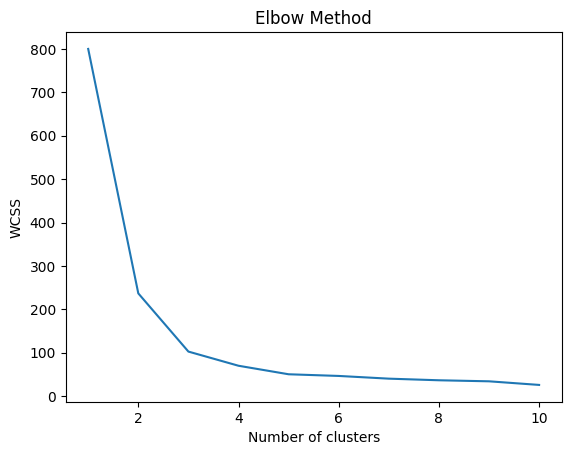

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for clustering (using length and width)
X_cluster = df[['length', 'width']].values

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Determine optimal number of clusters using elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

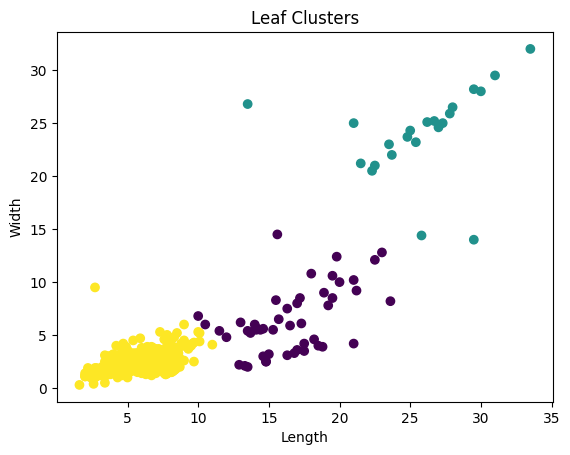

In [38]:
# Perform clustering with selected number of clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df['cluster'] = clusters

# Visualize the clusters
plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=clusters, cmap='viridis')
plt.xlabel('Length')
plt.ylabel('Width')
plt.title('Leaf Clusters')
plt.show()

In [41]:
df['cluster']

0      2
1      2
2      2
3      2
4      2
      ..
395    2
396    2
397    2
398    2
399    2
Name: cluster, Length: 400, dtype: int32

In [39]:
# Prepare features - now including cluster
X = df[['name', 'length', 'cluster']]
y = df['width']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot encode the name and cluster
oeh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_train_name_cluster = oeh.fit_transform(X_train[['name', 'cluster']])
encoded_test_name_cluster = oeh.transform(X_test[['name', 'cluster']])

# Get length values
length_train = X_train[['length']].to_numpy()
length_test = X_test[['length']].to_numpy()

# Combine features
X_train_final_array = np.concatenate((length_train, encoded_train_name_cluster), axis=1)
X_test_final_array = np.concatenate((length_test, encoded_test_name_cluster), axis=1)

# Get feature names
encoded_cols = oeh.get_feature_names_out(['name', 'cluster']).tolist()
final_columns = ['length'] + encoded_cols

# Create DataFrames
X_train_final = pd.DataFrame(X_train_final_array, columns=final_columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_final_array, columns=final_columns, index=X_test.index)

# Train the model
model = LinearRegression()
model.fit(X_train_final, y_train)

# Make predictions
y_pred = model.predict(X_test_final)

# Evaluate
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))

Mean Squared Error: 0.7068643512816063
Root Mean Squared Error: 0.8407522532123278


In [40]:
def predict_width(name, length):
    # First predict the cluster
    # We need to scale the input like we did during clustering
    scaled_input = scaler.transform([[length, 0]])  # 0 is placeholder for width
    
    # Predict cluster
    cluster = kmeans.predict(scaled_input[:, :1])[0]  # Only use length for prediction
    
    # Prepare input for regression
    input_data = pd.DataFrame({'name': [name], 'length': [length], 'cluster': [cluster]})
    
    # One-hot encode
    encoded_input = oeh.transform(input_data[['name', 'cluster']])
    
    # Combine features
    final_input = np.concatenate(([[length]], encoded_input), axis=1)
    final_input_df = pd.DataFrame(final_input, columns=final_columns)
    
    # Predict width
    width = model.predict(final_input_df)
    
    return width[0]

# Example usage:
name = "seetha"
length = 5.0
predicted_width = predict_width(name, length)
print(f"Predicted width for {name} with length {length}: {predicted_width:.2f}")

ValueError: X has 1 features, but KMeans is expecting 2 features as input.

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df[['name', 'length']]
y = df['width']

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [15]:
X_train

,name,length
3,seetha,5.2
18,seetha,5.4
202,pathar chatta,8.0
250,Neelamari (mitali),3.8
274,Sravanthi,5.0
...,...,...
71,mouha,19.5
106,Aswaganda,3.6
270,Sravanthi,4.0
348,jade plant,3.6


In [16]:
X_test

,name,length
209,pathar chatta,3.5
280,Anjeer,25.4
33,kaju,4.0
210,pathar chatta,8.1
93,lemon,2.2
...,...,...
246,Neelamari (mitali),6.4
227,Tej,7.8
369,muleti,7.7
176,conder,3.3


In [17]:
from sklearn.preprocessing import OneHotEncoder
oeh = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
encoded_train_name = oeh.fit_transform(X_train[['name']])
encoded_test_name = oeh.transform(X_test[['name']])

In [18]:
encoded_train_name

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [19]:
length_train = X_train[['length']].to_numpy()
length_test = X_test[['length']].to_numpy()


In [20]:
X_train_final_array = np.concatenate((length_train, encoded_train_name), axis=1)
X_test_final_array = np.concatenate((length_test, encoded_test_name), axis=1)

In [21]:
encoded_cols = oeh.get_feature_names_out(['name']).tolist()
final_columns = ['length'] + encoded_cols

In [22]:
X_train_final = pd.DataFrame(X_train_final_array, columns=final_columns, index=X_train.index)
X_test_final = pd.DataFrame(X_test_final_array, columns=final_columns, index=X_test.index)


In [23]:
X_train_final

,length,name_Anjeer,name_Aswaganda,name_Neelamari (mitali),name_Neem,name_Sravanthi,name_Tej,name_ajvine,name_conder,name_elachi,...,name_kaju,name_lemon,name_long,name_mouha,name_muleti,name_pathar chatta,name_sarso,name_seetha,name_sidha payam,name_tulsi
3,5.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18,5.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
202,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
250,3.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
274,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,19.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
106,3.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
270,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
348,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()
model.fit(X_train_final, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = model.predict(X_test_final)


In [27]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)


0.7728298011210729

In [28]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.8791073888445443

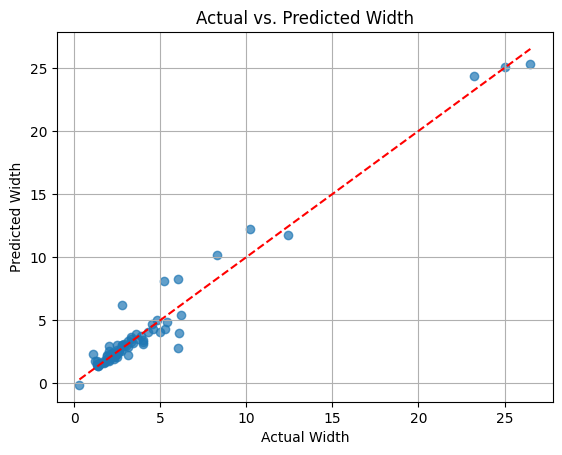

In [29]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Width')
plt.ylabel('Predicted Width')
plt.title('Actual vs. Predicted Width')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()


In [30]:
import joblib
joblib.dump(model, 'width_predictor_model.pkl')
joblib.dump(oeh, 'name_encoder.pkl')


['name_encoder.pkl']

#Prediction

In [31]:
loaded_model = joblib.load('width_predictor_model.pkl')
loaded_encoder = joblib.load('name_encoder.pkl')

new_data = pd.DataFrame([{'name': 'seetha', 'length': 6.0}])


new_encoded_name = loaded_encoder.transform(new_data[['name']])
new_log_length = np.log1p(new_data[['length']].to_numpy())


final_input = np.concatenate((new_log_length, new_encoded_name), axis=1)


predicted_width = loaded_model.predict(final_input)
print(f"Predicted width: {predicted_width[0]:.2f}")


Predicted width: 1.11


C:\Users\prabh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
